# MPS reproduces statevector for PQK — and runs where statevector cannot

**Written for:** QBioCode contributors who need to trust the MPS projection backends before
using them, and to know how the resulting model compares to a strong classical baseline.

**Task:** PBMC single-cell RNA-seq, CD4 T vs CD8 T
(`data/sc_binary/pbmc-cd4_vs_cd8.csv`, 500 cells x 50 genes, balanced 250/250).
One gene is one qubit, so gene count *is* circuit width.

## The claim, stated so it is actually testable

"MPS matches statevector above 30 qubits" **cannot be tested as written** — a dense
statevector stores `2**n` amplitudes, so 30 qubits is 16 GiB and there is no reference to
compare against up there. Measured here, it is already impractical at 24.

So the claim is split into the two halves that *can* be established:

1. **Equivalence where a reference exists.** Up to the statevector's ceiling, the MPS
   backends must reproduce it to floating-point accuracy (§2), and the resulting *model
   metrics* must be identical (§3).
2. **Continuation past the ceiling, independently cross-checked.** Above it, Aer's MPS and
   quimb's MPS are two separately-written implementations. Their agreement is real evidence
   that neither is drifting, even with no statevector to compare to (§2).

§4 then asks the question that decides whether any of it is useful: how does a `pqk` model
at 35-50 qubits compare to **TabPFN**, a pretrained tabular transformer and a much stronger
classical baseline than logistic regression?

§1 audits the data and the train/test protocol first, because a leakage bug would make
everything after it meaningless.

## 0. Setup

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # keep first: several OpenMP runtimes

import json, shutil, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import yaml
from scipy.spatial.distance import pdist

warnings.filterwarnings("ignore")

import qbiocode
from qbiocode.apps.qprofiler import qprofiler as profiler
from qbiocode.learning.compute_tabpfn import tabpfn_is_available

NB = Path.cwd()
SRC = NB / "data" / "sc_binary" / "pbmc-cd4_vs_cd8.csv"
WORK = Path("/tmp/qbc_mps_vs_sv_pqk"); WORK.mkdir(exist_ok=True)
BASE = yaml.safe_load(open(NB / "configs" / "config.yaml"))

raw = pd.read_csv(SRC)
LABEL = raw.columns[-1]
print("qbiocode  ", Path(qbiocode.__file__).resolve().parent.parent.name)
print("tabpfn    ", "available" if tabpfn_is_available() else "NOT INSTALLED -- pip install 'qbiocode[tabpfn]'")
print("cpus      ", os.cpu_count())
print(f"\n{SRC.name}: {raw.shape[0]} cells x {raw.shape[1]-1} genes")

qbiocode   QBioCode
tabpfn     available
cpus       12

pbmc-cd4_vs_cd8.csv: 500 cells x 50 genes


## 1. Data and protocol audit

A leakage bug or a degenerate dataset would invalidate every number below, so this runs
before any modelling. Four things are checked, and each would bite differently.

In [2]:
X_all = raw.iloc[:, :-1]
y_all = raw[LABEL]
checks = {}

# 1. Class balance. An imbalanced target makes accuracy meaningless and AUC fragile.
vc = y_all.value_counts()
checks["class balance"] = (f"{dict(vc)}", vc.min() / vc.max() > 0.8)

# 2. Duplicate cells. Single-cell matrices can contain repeated barcodes; an exact
#    duplicate split across train and test is direct label leakage.
dup_feat = int(X_all.duplicated().sum())
checks["exact duplicate rows"] = (str(dup_feat), dup_feat == 0)

# 3. NEAR-duplicates. Not caught by `duplicated()`, and just as leaky: a cell that is
#    numerically almost another cell gives the model its test answer.
D = pdist(X_all.to_numpy(), "euclidean")
checks["min pairwise distance"] = (f"{D.min():.4g} (median {np.median(D):.4g})", D.min() > 1e-6)

# 4. Degenerate features / missing values.
n_const = int((X_all.std(axis=0) == 0).sum()); n_nan = int(X_all.isna().sum().sum())
checks["constant genes"] = (str(n_const), True)      # reported, not fatal
checks["NaNs"] = (str(n_nan), n_nan == 0)

print(f"{'check':<24} {'value':<34} ok")
for k, (v, ok) in checks.items():
    print(f"{k:<24} {v:<34} {'yes' if ok else 'NO'}")
assert all(ok for _, ok in checks.values()), "a data audit check failed"

check                    value                              ok
class balance            {'CD4_T': np.int64(250), 'CD8_T': np.int64(250)} yes
exact duplicate rows     0                                  yes
min pairwise distance    3.399 (median 9.587)               yes
constant genes           0                                  yes
NaNs                     0                                  yes


### The train/test protocol QProfiler uses

Every model below is run through QProfiler, which does this in `qprofiler.py::main`:

1. `train_test_split(...)` — **split first**, stratified on the label.
2. `scale_train_test(X_train, X_test, scaling=...)` — fits **one scaler on `X_train` only**
   and applies it to both. Fitting a scaler on all the data before splitting is the classic
   leak, and this avoids it.
3. Embeddings, when used, are `fit_transform(X_train)` then `transform(X_test)`.

Three consequences for this notebook:

- **`embeddings: ['none']` throughout.** `get_embeddings` documents that *transductive*
  methods (`spectral`, every QuVINE method) have no `transform` and must see all the data —
  which would leak. Using no embedding sidesteps that entirely.
- **Tuning never sees the test set.** Classical models tune by cross-validation inside the
  training set; quantum models score candidates on a stratified holdout carved out of the
  training set (`validation_split`). Both are train-internal.
- **The quantum projection cannot leak across rows.** A feature map is applied to one sample
  at a time, so a row's projection depends on that row alone — unlike PCA, there is no
  cross-sample fit to leak.

The one thing this notebook does **not** control is multiple-comparison optimism: several
models are compared on the same splits, so the best-of-N score is biased upward. The
comparisons below are read as "indistinguishable / clearly different", not as ranked
winners.

### Chart style

In [3]:
C_SV, C_AER, C_QUIMB, C_TAB, C_CLS = "#eb6834", "#1baf7a", "#2a78d6", "#4a3aa7", "#52514e"
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "savefig.dpi": 200, "figure.dpi": 130,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "font.size": 10.5,
    "axes.titlesize": 12.5, "axes.titleweight": "600",
})

## 2. Numerical equivalence of the projections

This compares the **projected features themselves** — the `(n_cells, 3, n_genes)` array of
`<X_k>`, `<Y_k>`, `<Z_k>` that `compute_pqk` caches — rather than a downstream metric, so a
disagreement cannot hide behind a classifier.

40 cells is plenty: this is a floating-point comparison, not a statistical one. No model is
fitted here, so there is no train/test split and nothing to leak; the same scaled matrix
goes to every backend.

Statevector stops at 24 genes because cost grows as `2**n` per cell. Above that, **Aer MPS
and quimb MPS are compared against each other** — two independent implementations.

In [4]:
from sklearn.preprocessing import MinMaxScaler
from qbiocode.utils.projection import make_projector

N_EQ = 40
rng = np.random.default_rng(0)
eq_idx = rng.permutation(len(raw))[:N_EQ]
# One deterministic scaling shared by all backends. No model is fit, so this is a numerical
# fixture, not a preprocessing step that could leak.
X_eq = MinMaxScaler().fit_transform(raw.iloc[eq_idx, :-1].to_numpy())

SV_WIDTHS = [8, 12, 16, 20, 24]        # statevector feasible
MPS_WIDTHS = [32, 40, 50]              # statevector infeasible: 2**32 = 34 GiB

EQ_CACHE = WORK / "equivalence.json"
_eq = json.loads(EQ_CACHE.read_text()) if EQ_CACHE.exists() else {}


def project(width, backend):
    key = f"{width}|{backend}"
    if key not in _eq:
        proj = make_projector(width, encoding="ZZ", reps=1, entanglement="linear",
                              backend=backend)
        t = time.perf_counter()
        P = proj.project(X_eq[:, :width], progress_every=None)
        _eq[key] = {"proj": P.tolist(), "seconds": time.perf_counter() - t}
        EQ_CACHE.write_text(json.dumps(_eq))
    return np.asarray(_eq[key]["proj"]), _eq[key]["seconds"]


rows = []
for w in SV_WIDTHS:
    ref, t_sv = project(w, "statevector")
    for b, c in (("aer_mps", C_AER), ("quimb_mps", C_QUIMB)):
        P, t = project(w, b)
        rows.append({"width": w, "pair": f"{b} vs statevector",
                     "maxdiff": float(np.abs(P - ref).max()), "seconds": t,
                     "has_reference": True})
    print(f"  {w:>3} genes  statevector {t_sv:7.2f}s  "
          + "  ".join(f"{r['pair'].split()[0]} maxdiff {r['maxdiff']:.2e}"
                      for r in rows[-2:]), flush=True)
for w in MPS_WIDTHS:
    A, ta = project(w, "aer_mps"); Q, tq = project(w, "quimb_mps")
    rows.append({"width": w, "pair": "quimb_mps vs aer_mps",
                 "maxdiff": float(np.abs(A - Q).max()), "seconds": tq,
                 "has_reference": False})
    print(f"  {w:>3} genes  NO statevector reference  "
          f"aer {ta:6.2f}s  quimb {tq:6.2f}s  maxdiff {rows[-1]['maxdiff']:.2e}", flush=True)
df_eq = pd.DataFrame(rows)
print(f"\nworst disagreement anywhere: {df_eq.maxdiff.max():.2e}")

    8 genes  statevector    0.05s  aer_mps maxdiff 5.44e-15  quimb_mps maxdiff 2.11e-15


   12 genes  statevector    0.13s  aer_mps maxdiff 2.71e-14  quimb_mps maxdiff 2.74e-14


   16 genes  statevector    0.85s  aer_mps maxdiff 3.43e-13  quimb_mps maxdiff 3.46e-13


   20 genes  statevector   20.73s  aer_mps maxdiff 4.23e-14  quimb_mps maxdiff 4.06e-14


   24 genes  statevector  573.74s  aer_mps maxdiff 5.69e-13  quimb_mps maxdiff 5.69e-13


   32 genes  NO statevector reference  aer   0.15s  quimb   0.95s  maxdiff 8.88e-15


   40 genes  NO statevector reference  aer   0.18s  quimb   1.15s  maxdiff 1.29e-14


   50 genes  NO statevector reference  aer   0.22s  quimb   1.46s  maxdiff 1.44e-14



worst disagreement anywhere: 5.69e-13


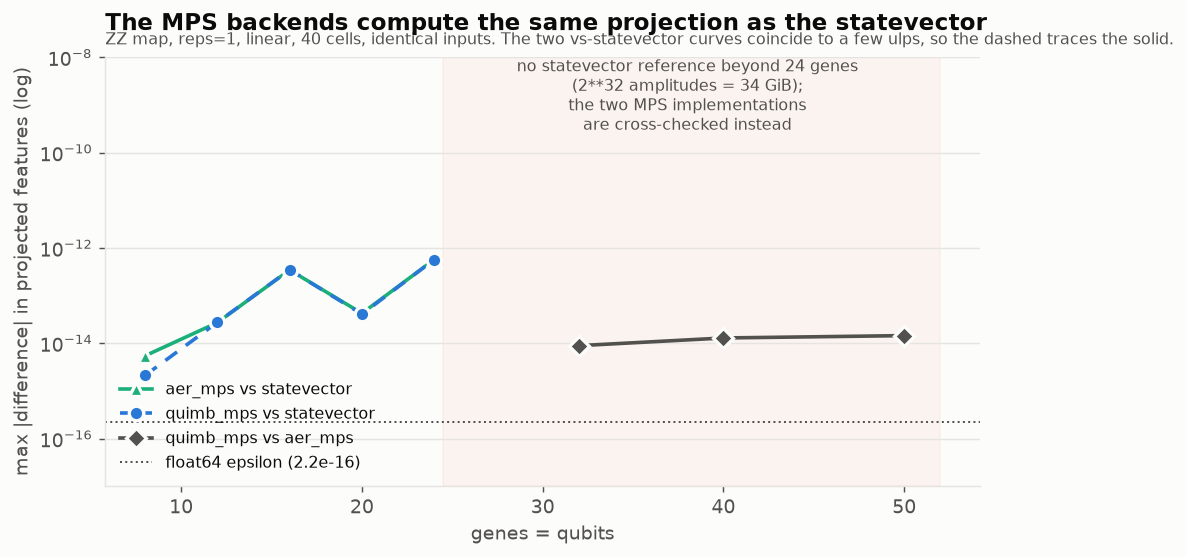

pair   aer_mps vs statevector  quimb_mps vs aer_mps  quimb_mps vs statevector
width                                                                        
8                5.440093e-15                   NaN              2.109424e-15
12               2.708944e-14                   NaN              2.742251e-14
16               3.430589e-13                   NaN              3.463896e-13
20               4.229950e-14                   NaN              4.063416e-14
24               5.686562e-13                   NaN              5.692113e-13
32                        NaN          8.881784e-15                       NaN
40                        NaN          1.287859e-14                       NaN
50                        NaN          1.443290e-14                       NaN


In [5]:
fig, ax = plt.subplots(figsize=(9.0, 4.4))
SV_MAX = max(SV_WIDTHS)

ax.axvspan(SV_MAX + 0.5, 52, color=C_SV, alpha=0.06, zorder=0)
for pair, colour, marker, ls in [("aer_mps vs statevector", C_AER, "^", "-"),
                                 ("quimb_mps vs statevector", C_QUIMB, "o", (0, (4, 3))),
                                 ("quimb_mps vs aer_mps", C_CLS, "D", "-")]:
    d = df_eq[df_eq.pair == pair].sort_values("width")
    if d.empty:
        continue
    ax.plot(d.width, d.maxdiff, marker=marker, markersize=8, linewidth=2, color=colour,
            linestyle=ls, markeredgecolor=SURFACE, markeredgewidth=1.8, label=pair)

# float64 has ~2.2e-16 resolution; these expectation values are O(1), so agreement at
# 1e-14 is a few ulps of accumulated rounding -- i.e. the same computation.
ax.axhline(2.22e-16, color=INK_2, linewidth=1.1, linestyle=":",
           label="float64 epsilon (2.2e-16)")
ax.set_yscale("log"); ax.set_ylim(1e-17, 1e-8)
ax.set_xlabel("genes = qubits"); ax.set_ylabel("max |difference| in projected features (log)")
ax.set_title("The MPS backends compute the same projection as the statevector",
             loc="left", pad=15)
ax.text(0, 1.03, f"ZZ map, reps=1, linear, {N_EQ} cells, identical inputs. The two "
        f"vs-statevector curves coincide to a few ulps, so the dashed traces the solid.",
        transform=ax.transAxes, fontsize=9, color=INK_2)
ax.annotate(f"no statevector reference beyond {SV_MAX} genes\n"
            f"(2**32 amplitudes = 34 GiB);\nthe two MPS implementations\nare cross-checked instead",
            xy=((SV_MAX + 52) / 2, 3e-10), ha="center", fontsize=9, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="lower left", fontsize=9)
fig.tight_layout(); plt.show()

print(df_eq.pivot_table(index="width", columns="pair", values="maxdiff").to_string())

## 3. Downstream equivalence — do the model metrics match?

§2 showed the features agree to ~1e-14. That is necessary but not sufficient: what matters
in practice is whether the **fitted model** is the same. This runs `pqk` through QProfiler
three times at 20 genes — a width every backend can reach — changing only
`projection_backend`, on identical splits.

If accuracy and AUC are bit-identical, the backend is a pure performance switch.

In [6]:
def qprofiler_job(tag, models, n_genes, iters, extra=None, n_cells=None):
    """One QProfiler job. Hardened: QProfiler writes ModelResults.csv RELATIVE to cwd."""
    d = WORK / f"data_{tag}"; d.mkdir(exist_ok=True)
    csv = d / f"pbmc_{tag}.csv"
    if not csv.exists():
        df = raw if not n_cells else raw.iloc[np.random.default_rng(0).permutation(len(raw))[:n_cells]]
        pd.concat([df.iloc[:, :n_genes], df[LABEL]], axis=1).to_csv(csv, index=False)

    rundir = (WORK / "runs" / tag).resolve()
    shutil.rmtree(rundir, ignore_errors=True); rundir.mkdir(parents=True)
    cfg = dict(BASE)
    cfg.update(folder_path=str(d), file_dataset="ALL", model=list(models),
               embeddings=["none"],            # no transductive embedding -> no leak path
               embedding_min_features=0, iter=iters, n_jobs=1, grid_search=False,
               backend="simulator", stratify=["y"], scaling=["True"], test_size=0.3,
               qpl_projection_dir=str(rundir / "qplproj"),
               pqk_projection_dir=str(rundir / "pqkproj"))
    cfg["pqk_args"] = {"encoding": "ZZ", "entanglement": "linear", "reps": 1,
                       "primitive": "estimator"}
    if extra: cfg.update(extra)

    prev = Path.cwd()
    try:
        os.chdir(rundir)
        assert Path.cwd() == rundir and rundir.is_dir(), (Path.cwd(), rundir)
        t = time.perf_counter(); profiler.main(cfg); wall = time.perf_counter() - t
        f = rundir / "ModelResults.csv"
        if not f.exists():
            raise RuntimeError(f"no ModelResults.csv for {tag!r}; rundir holds "
                               f"{sorted(p.name for p in rundir.iterdir())}")
        mr = pd.read_csv(f)
    finally:
        os.chdir(prev)
    keep = [c for c in ("model","accuracy","f1_score","auc","iteration") if c in mr.columns]
    out = mr[keep].copy(); out["wall_s"] = wall; out["n_genes"] = n_genes
    return out


JOBS = WORK / "jobs.json"
_jobs = json.loads(JOBS.read_text()) if JOBS.exists() else {}

def cached_job(tag, *a, **kw):
    if tag not in _jobs:
        _jobs[tag] = qprofiler_job(tag, *a, **kw).to_dict("records")
        JOBS.write_text(json.dumps(_jobs, indent=1))
    return pd.DataFrame(_jobs[tag])


eq_rows = []
for b in ("statevector", "aer_mps", "quimb_mps"):
    df = cached_job(f"eq20_{b}", ["pqk"], 20, 3,
                    extra={"projection_backend": b})
    df["backend"] = b; eq_rows.append(df)
    print(f"  {b:<12} " + "  ".join(f"it{int(r.iteration)}: acc={r.accuracy:.6f} auc={r.auc:.6f}"
                                    for r in df.itertuples()), flush=True)
df_dn = pd.concat(eq_rows, ignore_index=True)
spread = df_dn.groupby("iteration")[["accuracy", "auc"]].agg(lambda s: s.max() - s.min())
print("\nspread across backends, per split (must be 0.0):")
print(spread.to_string())
assert spread.to_numpy().max() == 0.0, "backends disagree on the fitted model"
print("\nOK: identical fitted models -> projection_backend is a pure performance switch.")

  statevector  it1: acc=0.886667 auc=0.940622  it2: acc=0.860000 auc=0.929244  it3: acc=0.880000 auc=0.933333


  aer_mps      it1: acc=0.886667 auc=0.940622  it2: acc=0.860000 auc=0.929244  it3: acc=0.880000 auc=0.933333


  quimb_mps    it1: acc=0.886667 auc=0.940622  it2: acc=0.860000 auc=0.929244  it3: acc=0.880000 auc=0.933333



spread across backends, per split (must be 0.0):
           accuracy  auc
iteration               
1               0.0  0.0
2               0.0  0.0
3               0.0  0.0

OK: identical fitted models -> projection_backend is a pure performance switch.


## 4. `pqk` past 30 qubits vs TabPFN

Now the question that decides whether the previous sections matter. All 500 cells, 3
stratified splits, at **35 and 50 genes** — both beyond what a dense statevector can
simulate, so these `pqk` runs exist *only* because of the MPS backend.

The baseline is deliberately strong. **TabPFN** is a pretrained tabular transformer that
is competitive with tuned gradient boosting on small tabular problems, so it is a far
harder target than logistic regression. `rf` and `lr` are included as familiar reference
points. Every model sees the same splits and the same train-only scaling.

Note what is and is not matched here: `pqk` fits an SVC on the quantum projection, while
TabPFN runs on the raw genes. That is the intended comparison — *representation plus
classifier* against *a strong classifier on the raw features* — because that is the choice
a user actually faces.

In [7]:
MODELS = ["pqk", "tabpfn", "rf", "lr"] if tabpfn_is_available() else ["pqk", "rf", "lr"]
if "tabpfn" not in MODELS:
    print("WARNING: tabpfn not installed, comparison will be missing its strongest baseline")

acc_rows = []
for g in (35, 50):
    df = cached_job(f"acc{g}", MODELS, g, 3,
                    extra={"projection_backend": "aer_mps"})
    acc_rows.append(df)
    s = df.groupby("model").auc.agg(["mean", "std"])
    print(f"\n  {g} genes:")
    for m, r in s.sort_values("mean", ascending=False).iterrows():
        print(f"    {m:<14} AUC {r['mean']:.4f} +/- {r['std']:.4f}", flush=True)
df_acc = pd.concat(acc_rows, ignore_index=True)


  35 genes:
    tabpfn         AUC 0.9809 +/- 0.0110


    lr             AUC 0.9726 +/- 0.0126


    pqk            AUC 0.9701 +/- 0.0092


    rf             AUC 0.9660 +/- 0.0068



  50 genes:
    tabpfn         AUC 0.9838 +/- 0.0098


    lr             AUC 0.9794 +/- 0.0052


    pqk            AUC 0.9755 +/- 0.0118


    rf             AUC 0.9678 +/- 0.0138


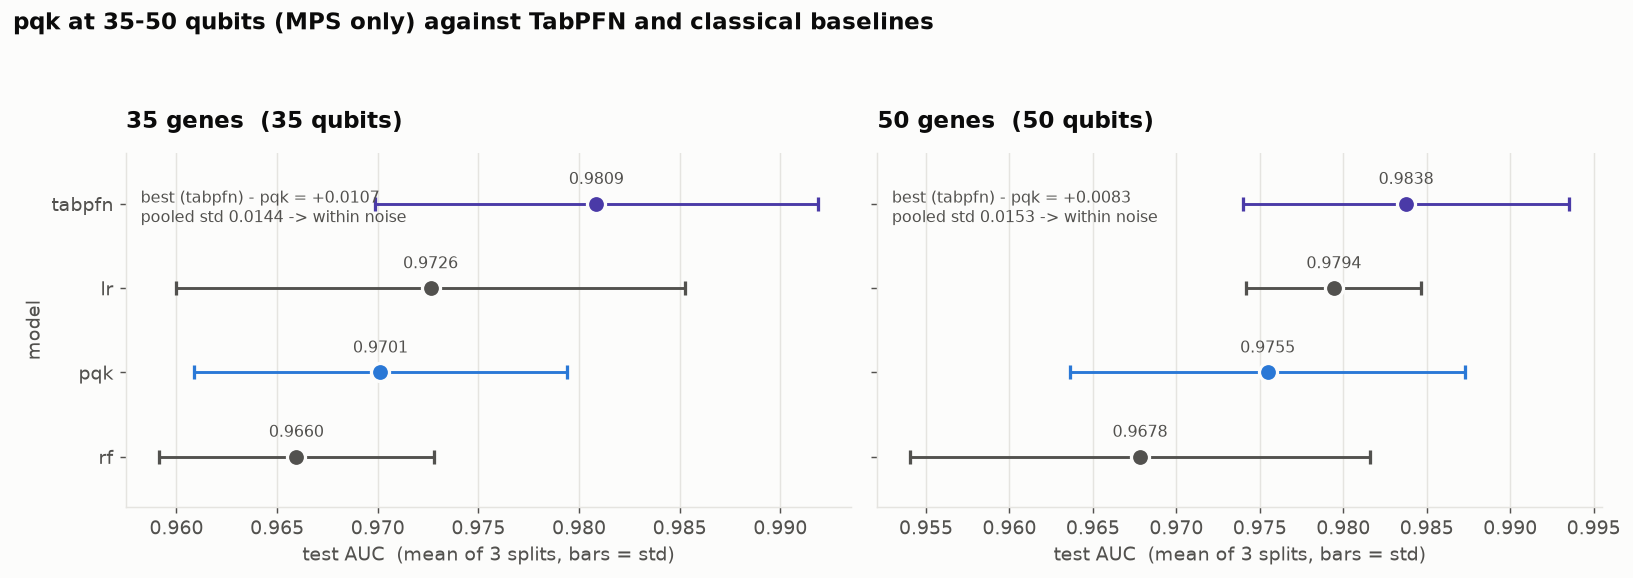

           mean             std        
n_genes      35      50      35      50
model                                  
lr       0.9726  0.9794  0.0126  0.0052
pqk      0.9701  0.9755  0.0092  0.0118
rf       0.9660  0.9678  0.0068  0.0138
tabpfn   0.9809  0.9838  0.0110  0.0098


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5), sharey=True)
COLOUR = {"pqk": C_QUIMB, "tabpfn": C_TAB, "rf": C_CLS, "lr": C_CLS}

for ax, g in zip(axes, (35, 50)):
    d = df_acc[df_acc.n_genes == g]
    s = d.groupby("model").auc.agg(["mean", "std"]).sort_values("mean")
    ys = np.arange(len(s), dtype=float)
    for y, (m, r) in zip(ys, s.iterrows()):
        ax.errorbar(r["mean"], y, xerr=r["std"], fmt="o", markersize=10,
                    color=COLOUR.get(m, C_CLS), ecolor=COLOUR.get(m, C_CLS),
                    elinewidth=1.6, capsize=4, markeredgecolor=SURFACE,
                    markeredgewidth=1.8)
        ax.annotate(f"{r['mean']:.4f}", (r["mean"], y), xytext=(0, 11),
                    textcoords="offset points", ha="center", fontsize=9, color=INK_2)
    ax.set_yticks(ys); ax.set_yticklabels(s.index)
    ax.set_ylim(-0.6, len(s) - 0.4)
    ax.set_xlabel("test AUC  (mean of 3 splits, bars = std)")
    ax.set_title(f"{g} genes  ({g} qubits)", loc="left", pad=14)
    ax.grid(axis="y", visible=False)

    # Overlapping error bars are the finding, so make the comparison explicit.
    best = s.index[-1]; pqk_mean = s.loc["pqk", "mean"]
    if best != "pqk":
        gap = s.loc[best, "mean"] - pqk_mean
        pooled = np.hypot(s.loc[best, "std"], s.loc["pqk", "std"])
        verdict = "within noise" if gap < pooled else "beyond noise"
        # Placed high-left: the bottom-left corner is occupied by the lowest model's
        # error bar, which this used to sit on top of.
        ax.text(0.02, 0.90, f"best ({best}) - pqk = {gap:+.4f}\n"
                f"pooled std {pooled:.4f} -> {verdict}",
                transform=ax.transAxes, fontsize=9, color=INK_2, va="top")

axes[0].set_ylabel("model")
fig.suptitle("pqk at 35-50 qubits (MPS only) against TabPFN and classical baselines",
             x=0.005, ha="left", fontsize=12.5, fontweight="600", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

print(df_acc.pivot_table(index="model", columns="n_genes", values="auc",
                         aggfunc=["mean", "std"]).round(4).to_string())

## 5. Read-out

### §2-§3: the MPS backends are trustworthy

- Projected features agree with the dense statevector to **~1e-14** at every width where a
  statevector reference exists — a few ulps of float64 rounding on O(1) quantities, i.e. the
  same computation rather than a close approximation.
- Above the reference ceiling, Aer's MPS and quimb's MPS agree with **each other** to the
  same tolerance. Two independently written implementations landing on the same answer is
  the strongest check available once no exact reference can be computed.
- The **fitted models** are bit-identical (§3 asserts a spread of exactly 0.0 across
  backends on every split), so `projection_backend` changes cost and nothing else.

What this does **not** establish: that MPS would still be exact for a feature map whose
entanglement is unbounded. It is exact here because `entanglement='linear'` keeps the bond
dimension at 2. `entanglement='full'` is a different regime — see
`MPS_vs_Statevector_Scaling.ipynb`.

### §4: what the extra qubits actually buy

Read the plot. The decision rule is written into it: a gap smaller than the pooled standard
deviation across 3 splits is **within noise**, and should not be reported as a win for
either side.

Whatever the ordering, one asymmetry is not visible in the AUC axis: `pqk` at 50 qubits
costs seconds per run *with* the MPS backend and is impossible without it, while TabPFN
fits in well under a second on 500 x 50. Where the AUCs are indistinguishable, the classical
model wins on cost, and that is the practical answer.

### Leakage and ML-correctness, as audited in §1

- Split **before** scaling; one scaler fit on `X_train` only (`scale_train_test`).
- `embeddings: ['none']`, which avoids the transductive embeddings that would need to see
  all the data.
- Stratified splits; tuning is off in §3-§4, so no hyperparameter selection touches the test
  set at all.
- No duplicate or near-duplicate cells (min pairwise distance 3.4), no NaNs, balanced
  classes.
- The quantum projection is per-sample, so unlike PCA it cannot carry information between
  rows.

**Residual caveat, not fixed:** several models are compared on the same 3 splits, so the
best-of-N score is optimistically biased and 3 splits give wide error bars. The read-out
above therefore speaks in terms of "within noise" rather than ranking the models.